In [1]:
import sys
sys.path.insert(1, '/home/bricej/MyPythonLibrary/StageM2_IVT/library/')
import domain
from domain import *
from climbas import *
import numpy as np
import xarray as xr
import pandas as pd
from netCDF4 import Dataset
import dask
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import calendar

# Period & Domain

In [2]:
iyear=1981
fyear=2015
dom='HMA'
latS,latN,lonW,lonE = coord_domain(dom)

In [3]:
models = ['APHRO','GPCP','CRU','CHIRPS','HARv2','ERA5']

# Precipitation & elevation datas loading

In [5]:
#Run 'compute_tp_datasets_mm_month.py'

"""
model1='APHRO'
field1 = xr.open_dataset(f'/bettik/PROJECTS/pr-regional-climate/bricej/tp_datasets/tp_HMA_1951-2015_APHRO.nc')['tp']
field1=field1.sel(time=slice(str(iyear),str(fyear)))
field1=field_dom(field1,dom)

model2='GPCP'
field2 = xr.open_dataset(f'/bettik/PROJECTS/pr-regional-climate/bricej/tp_datasets/tp_HMA_1891-2019_GPCP.nc')['tp']
field2=field2.sel(time=slice(str(iyear),str(fyear)))
field2=field_dom(field2,dom)


model3='CRU'
field3 = xr.open_dataset(f'/bettik/PROJECTS/pr-regional-climate/bricej/tp_datasets/tp_HMA_1901-2020_CRU.nc')['tp']
field3=field3.sel(time=slice(str(iyear),str(fyear)))
field3=field_dom(field3,dom)


model4='CHIRPS'
field4 = xr.open_dataset(f'/bettik/PROJECTS/pr-regional-climate/bricej/tp_datasets/tp_HMA_1981-2025_CHIRPS.nc')['tp']
field4=field4.sel(time=slice(str(iyear),str(fyear)))
field4=field_dom(field4,dom)


model5='HARv2'
field5 = xr.open_dataset(f'/bettik/PROJECTS/pr-regional-climate/bricej/tp_datasets/tp_HMA_1980-2023_HARv2.nc')['tp']
field5=field5.sel(time=slice(str(iyear),str(fyear)))
def xy_sel_dom(ds,latS,latN,lonW,lonE):
    #latS,latN,lonW,lonE=coord_domain(domain)
    lat_str = ''
    lon_str = ''
    other_dims_str = []
    for dim in ds.coords:
        print(dim)
        if dim in ['lat', 'latitude','LON']:
            lat_str = dim
        elif dim in ['lon', 'longitude','LAT']:
            lon_str = dim
        else:
            other_dims_str.append(dim)
    mask = (
        (latS < ds[lat_str]) & ( ds[lat_str] < latN) 
    & (lonW < ds[lon_str]) & ( ds[lon_str] < lonE)
    )
    field_dom=ds.where(mask,drop=True)
    return field_dom
field5=xy_sel_dom(field5,latS,latN,lonW,lonE)


model6='ERA5'
field6 = xr.open_dataset(f'/bettik/PROJECTS/pr-regional-climate/bricej/tp_datasets/tp_HMA_1940-2025_ERA5.nc')['tp']
field6=field6.sel(time=slice(str(iyear),str(fyear)))
field6=field_dom(field6,dom)
"""

"\nmodel1='APHRO'\nfield1 = xr.open_dataset(f'/bettik/PROJECTS/pr-regional-climate/bricej/tp_datasets/tp_HMA_1951-2015_APHRO.nc')['tp']\nfield1=field1.sel(time=slice(str(iyear),str(fyear)))\nfield1=field_dom(field1,dom)\n\nmodel2='GPCP'\nfield2 = xr.open_dataset(f'/bettik/PROJECTS/pr-regional-climate/bricej/tp_datasets/tp_HMA_1891-2019_GPCP.nc')['tp']\nfield2=field2.sel(time=slice(str(iyear),str(fyear)))\nfield2=field_dom(field2,dom)\n\n\nmodel3='CRU'\nfield3 = xr.open_dataset(f'/bettik/PROJECTS/pr-regional-climate/bricej/tp_datasets/tp_HMA_1901-2020_CRU.nc')['tp']\nfield3=field3.sel(time=slice(str(iyear),str(fyear)))\nfield3=field_dom(field3,dom)\n\n\nmodel4='CHIRPS'\nfield4 = xr.open_dataset(f'/bettik/PROJECTS/pr-regional-climate/bricej/tp_datasets/tp_HMA_1981-2025_CHIRPS.nc')['tp']\nfield4=field4.sel(time=slice(str(iyear),str(fyear)))\nfield4=field_dom(field4,dom)\n\n\nmodel5='HARv2'\nfield5 = xr.open_dataset(f'/bettik/PROJECTS/pr-regional-climate/bricej/tp_datasets/tp_HMA_1980-2023

In [4]:
ds1_SH_raw=xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/santolam/gmted/'+'gmted_on_aphro.nc')['elevation']
ds1_SH=ds1_SH_raw.rename({'latitude':'lat','longitude':'lon'})
ds1_SH=reversing_lat(ds1_SH)
field1_SH=field_dom(ds1_SH,dom)

In [5]:
ds2_SH=xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/santolam/gmted/'+'gmted_on_gpcp.nc')['elevation']
field2_SH=field_dom(ds2_SH,dom)

In [6]:
ds3_SH_raw=xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/santolam/gmted/gmted_on_cru_hma_grid.nc')['elevation']
ds3_SH=reversing_lat(ds3_SH_raw)
field3_SH=field_dom(ds3_SH,dom)

In [7]:
ds4_SH=xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/santolam/gmted/'+'gmted_on_chirps_hma_grid.nc')['elevation']
ds4_SH=ds4_SH.rename({'latitude':'lat','longitude':'lon'})
ds4_SH=reversing_lat(ds4_SH)
field4_SH=field_dom(ds4_SH,dom)

In [8]:
def xy_sel_dom(ds,latS,latN,lonW,lonE):
    #latS,latN,lonW,lonE=coord_domain(domain)
    lat_str = ''
    lon_str = ''
    other_dims_str = []
    for dim in ds.coords:
        print(dim)
        if dim in ['lat', 'latitude','LON']:
            lat_str = dim
        elif dim in ['lon', 'longitude','LAT']:
            lon_str = dim
        else:
            other_dims_str.append(dim)
    mask = (
        (latS < ds[lat_str]) & ( ds[lat_str] < latN) 
    & (lonW < ds[lon_str]) & ( ds[lon_str] < lonE)
    )
    field_dom=ds.where(mask,drop=True)
    return field_dom

ds5_grM= xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/santolam/HARv2/HARv2_d10km_static_hgt.nc')
ds5_SH=ds5_grM['hgt'][0,:,:]
field5_SH=xy_sel_dom(ds5_SH,latS,latN,lonW,lonE)

time
west_east
south_north
lon
lat


In [9]:
ds6_SH=xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/santolam/gmted/gmted_on_era5_grid.nc')['elevation']
ds6_SH=ds6_SH.rename({'latitude':'lat','longitude':'lon'})
field6_SH=field_dom(ds6_SH,dom)

In [10]:
field_SH_dict = {
    models[0]: field1_SH,
    models[1]: field2_SH,
    models[2]: field3_SH,
    models[3]: field4_SH,
    models[4]: field5_SH,
    models[5]: field6_SH}

# Annual Climatology

In [11]:
# Run compute_tp_datasets_spatial_mean_annual.py

model1='APHRO'
tp_mean1 = xr.open_dataset(f'/bettik/PROJECTS/pr-regional-climate/bricej/results/climbas/spatial_mean_tp_annual_{dom}_{iyear}-{fyear}_{model1}.nc')['tp']

model2='GPCP'
tp_mean2 = xr.open_dataset(f'/bettik/PROJECTS/pr-regional-climate/bricej/results/climbas/spatial_mean_tp_annual_{dom}_{iyear}-{fyear}_{model2}.nc')['tp']

model3='CRU'
tp_mean3 = xr.open_dataset(f'/bettik/PROJECTS/pr-regional-climate/bricej/results/climbas/spatial_mean_tp_annual_{dom}_{iyear}-{fyear}_{model3}.nc')['tp']

model4='CHIRPS'
tp_mean4 = xr.open_dataset(f'/bettik/PROJECTS/pr-regional-climate/bricej/results/climbas/spatial_mean_tp_annual_{dom}_{iyear}-{fyear}_{model4}.nc')['tp']

model5='HARv2'
tp_mean5 = xr.open_dataset(f'/bettik/PROJECTS/pr-regional-climate/bricej/results/climbas/spatial_mean_tp_annual_{dom}_{iyear}-{fyear}_{model5}.nc')['tp']

model6='ERA5'
tp_mean6 = xr.open_dataset(f'/bettik/PROJECTS/pr-regional-climate/bricej/results/climbas/spatial_mean_tp_annual_{dom}_{iyear}-{fyear}_{model6}.nc')['tp']

tp_mean_dict = {
    models[0]: tp_mean1,
    models[1]: tp_mean2,
    models[2]: tp_mean3,
    models[3]: tp_mean4,
    models[4]: tp_mean5,
    models[5]: tp_mean6}

500


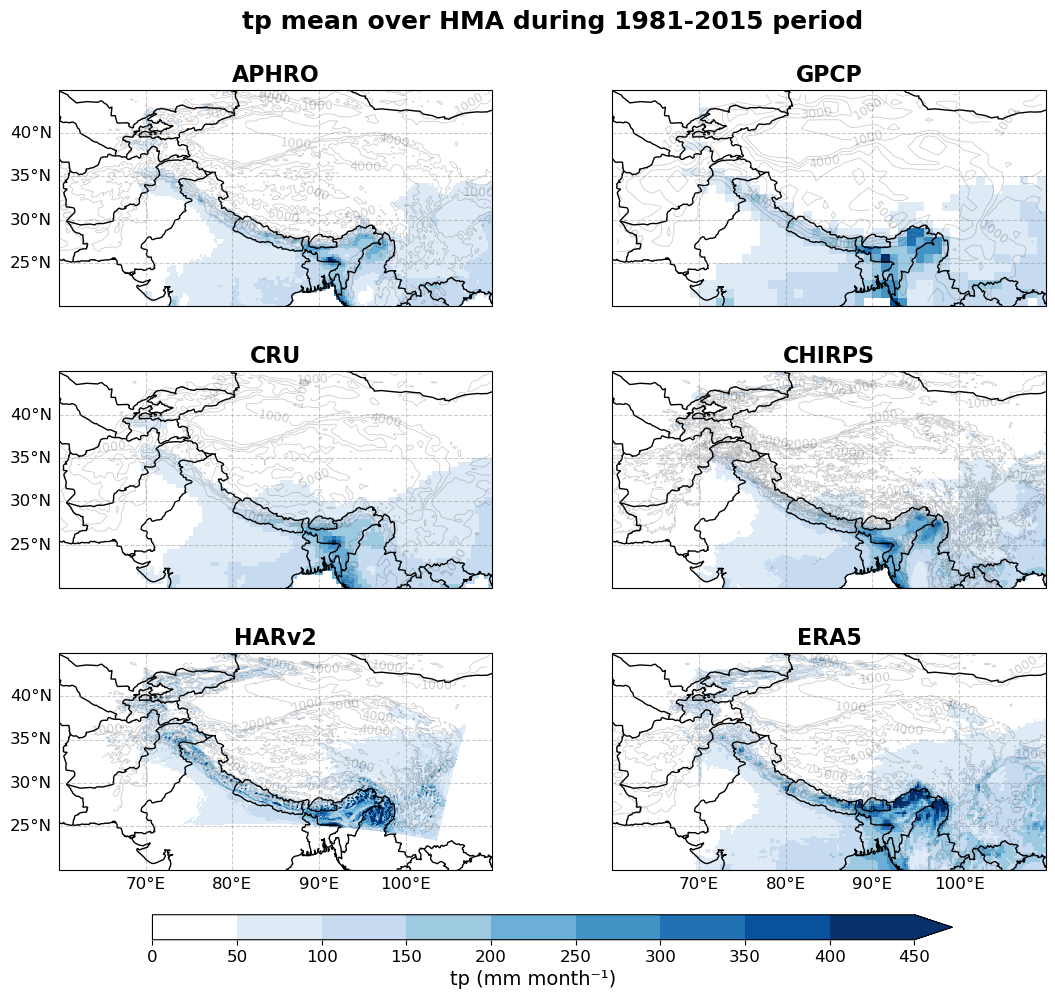

In [12]:
vmax = 500
#vmax = max(np.ceil(float(np.nanmax(np.abs(ds)))) for ds in tp_mean_dict.values())
print(vmax)
levels = np.arange(0, vmax, 50)
base_cmap = plt.get_cmap("Blues", len(levels)-1)
colors = base_cmap(np.arange(base_cmap.N))
colors[0] = [1, 1, 1, 1]  # blanc RGBA
cmap = mcolors.ListedColormap(colors)
norm = mcolors.BoundaryNorm(levels, ncolors=cmap.N)

fig, axes = plt.subplots(3, 2, figsize=(16, 10), subplot_kw={'projection': ccrs.PlateCarree()})
axes = axes.flatten()

for i, ax in enumerate(axes):
    model = models[i]
    data_model = tp_mean_dict[model]

    im = ax.pcolormesh(data_model['lon'],data_model['lat'],data_model,transform=ccrs.PlateCarree(),cmap=cmap,norm=norm,shading="auto")

    ax.set_extent([lonW,lonE,latS,latN], crs=ccrs.PlateCarree())
    
    ax.add_feature(cfeature.COASTLINE, linewidth=1)
    ax.add_feature(cfeature.BORDERS, linestyle="-")

    SH = ax.contour(field_SH_dict[model].lon,field_SH_dict[model].lat,field_SH_dict[model],levels=[1000,2000,3000,4000,5000,6000,7000],
                colors="k",linewidths=0.6,alpha=0.2,transform=ccrs.PlateCarree())
    ax.clabel(SH, inline=True, fontsize=9, fmt="%d")
    
    ax.set_title(model, fontsize=16, weight="bold")

    gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True,linewidth=0.8,color="gray",alpha=0.4,linestyle="--")
    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = (i % 2 == 0)
    gl.bottom_labels = (i >= 4) 
    gl.xlabel_style = {"size": 12}
    gl.ylabel_style = {"size": 12}

cbar_ax = fig.add_axes([0.25, 0.05, 0.5, 0.025])
cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal", extend='max')
cbar.set_label("tp (mm month⁻¹)", fontsize=14)
cbar.ax.tick_params(labelsize=12)

fig.subplots_adjust(left=0.08, right=0.92, top=0.90, bottom=0.12, wspace=-0.3, hspace=0.3)
plt.suptitle(f"tp mean over HMA during {iyear}-{fyear} period", fontsize=18, weight="bold")

plt.show()

# SEH zoom

In [30]:
latS2,latN2,lonW2,lonE2 = coord_domain('SEH')

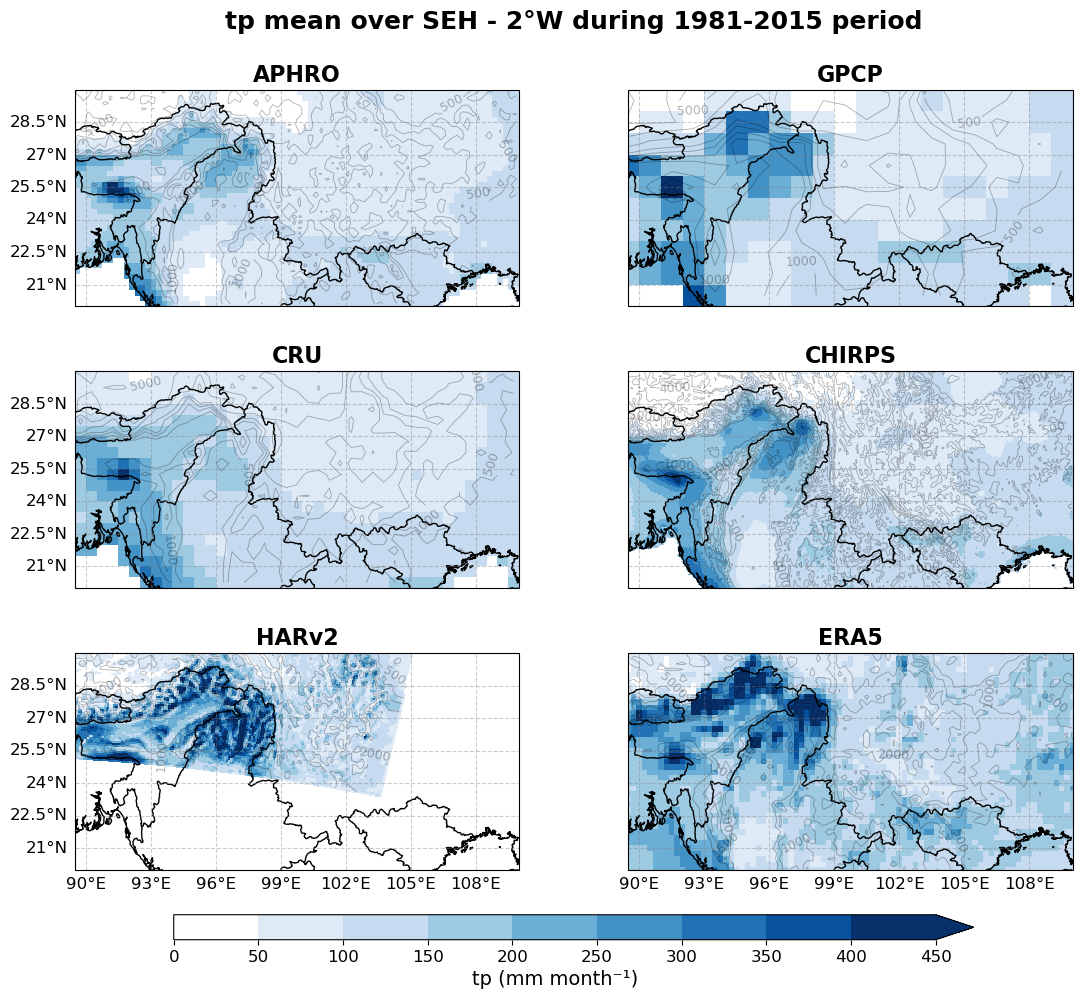

In [31]:
fig, axes = plt.subplots(3, 2, figsize=(16, 10), subplot_kw={'projection': ccrs.PlateCarree()})
axes = axes.flatten()

for i, ax in enumerate(axes):
    model = models[i]
    data_model = tp_mean_dict[model]

    im = ax.pcolormesh(data_model['lon'],data_model['lat'],data_model,transform=ccrs.PlateCarree(),cmap=cmap,norm=norm,shading="auto")

    ax.set_extent([lonW2 - 2,lonE2,latS2,latN2], crs=ccrs.PlateCarree())
    
    ax.add_feature(cfeature.COASTLINE, linewidth=1)
    ax.add_feature(cfeature.BORDERS, linestyle="-")

    SH = ax.contour(field_SH_dict[model].lon,field_SH_dict[model].lat,field_SH_dict[model],levels=[500,1000,1500,2000,3000,4000,5000,6000,7000],
                colors="k",linewidths=0.6,alpha=0.3,transform=ccrs.PlateCarree())
    ax.clabel(SH, inline=True, fontsize=9, fmt="%d")
    
    ax.set_title(model, fontsize=16, weight="bold")

    gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True,linewidth=0.8,color="gray",alpha=0.4,linestyle="--")
    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = (i % 2 == 0)
    gl.bottom_labels = (i >= 4) 
    gl.xlabel_style = {"size": 12}
    gl.ylabel_style = {"size": 12}

cbar_ax = fig.add_axes([0.25, 0.05, 0.5, 0.025])
cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal", extend='max')
cbar.set_label("tp (mm month⁻¹)", fontsize=14)
cbar.ax.tick_params(labelsize=12)

fig.subplots_adjust(left=0.08, right=0.92, top=0.90, bottom=0.12, wspace=-0.3, hspace=0.3)
plt.suptitle(f"tp mean over SEH - 2°W during {iyear}-{fyear} period", fontsize=18, weight="bold")

plt.show()

# Seasonal Climatology

# DJFM

In [37]:
# Run compute_tp_datasets_spatial_mean_season.py

season = 'DJFM'

model1='APHRO'
tp_season1 = xr.open_dataset(f'/bettik/PROJECTS/pr-regional-climate/bricej/results/climbas/spatial_mean_tp_{season}_{dom}_{iyear}-{fyear}_{model1}.nc')['tp']

model2='GPCP'
tp_season2 = xr.open_dataset(f'/bettik/PROJECTS/pr-regional-climate/bricej/results/climbas/spatial_mean_tp_{season}_{dom}_{iyear}-{fyear}_{model2}.nc')['tp']

model3='CRU'
tp_season3 = xr.open_dataset(f'/bettik/PROJECTS/pr-regional-climate/bricej/results/climbas/spatial_mean_tp_{season}_{dom}_{iyear}-{fyear}_{model3}.nc')['tp']

model4='CHIRPS'
tp_season4 = xr.open_dataset(f'/bettik/PROJECTS/pr-regional-climate/bricej/results/climbas/spatial_mean_tp_{season}_{dom}_{iyear}-{fyear}_{model4}.nc')['tp']

model5='HARv2'
tp_season5 = xr.open_dataset(f'/bettik/PROJECTS/pr-regional-climate/bricej/results/climbas/spatial_mean_tp_{season}_{dom}_{iyear}-{fyear}_{model5}.nc')['tp']

model6='ERA5'
tp_season6 = xr.open_dataset(f'/bettik/PROJECTS/pr-regional-climate/bricej/results/climbas/spatial_mean_tp_{season}_{dom}_{iyear}-{fyear}_{model6}.nc')['tp']

tp_season_dict = {
    models[0]: tp_season1,
    models[1]: tp_season2,
    models[2]: tp_season3,
    models[3]: tp_season4,
    models[4]: tp_season5,
    models[5]: tp_season6}

field_SH_dict = {
    models[0]: field1_SH,
    models[1]: field2_SH,
    models[2]: field3_SH,
    models[3]: field4_SH,
    models[4]: field5_SH,
    models[5]: field6_SH}

250


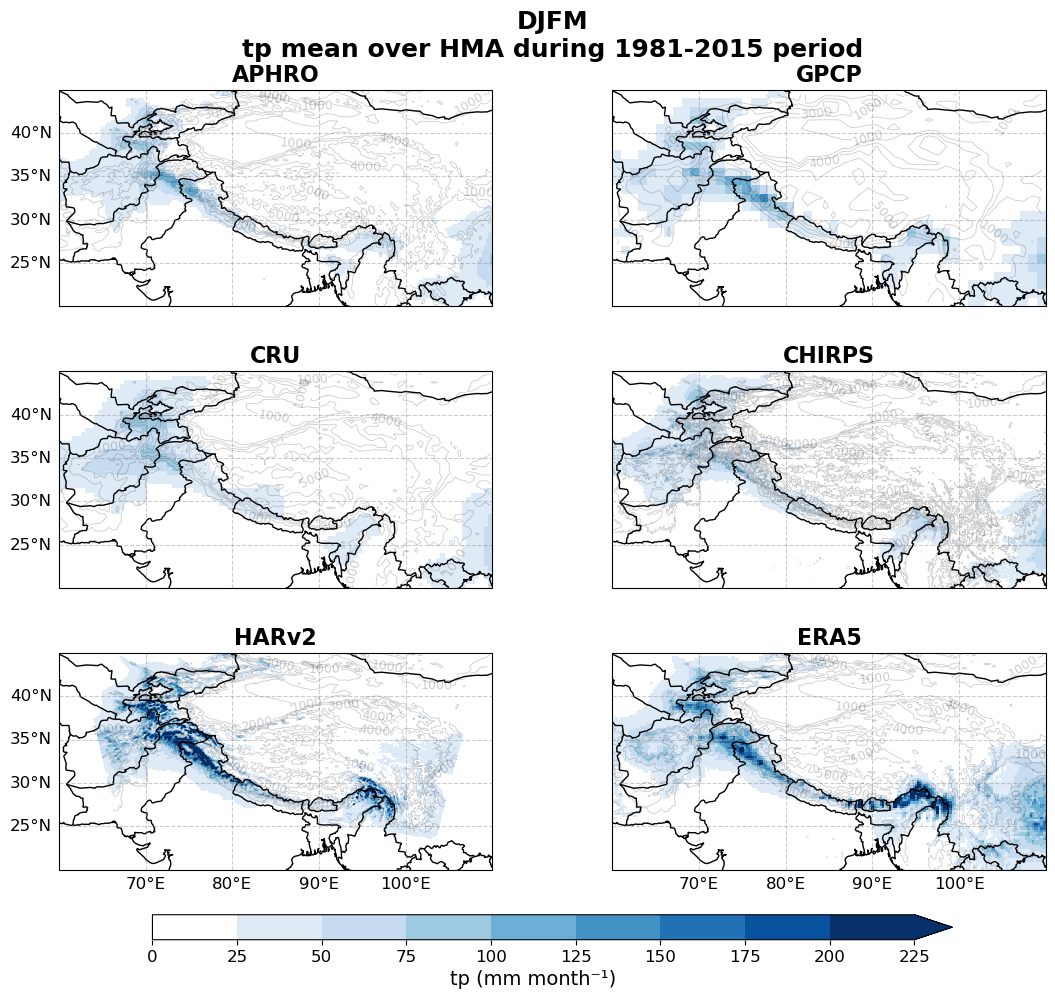

In [39]:
vmax = 250
#vmax = max(np.ceil(float(np.nanmax(np.abs(ds)))) for ds in tp_mean_dict.values())
print(vmax)
levels = np.arange(0, vmax, 25)
base_cmap = plt.get_cmap("Blues", len(levels)-1)
colors = base_cmap(np.arange(base_cmap.N))
colors[0] = [1, 1, 1, 1]  # blanc RGBA
cmap = mcolors.ListedColormap(colors)
norm = mcolors.BoundaryNorm(levels, ncolors=cmap.N)

fig, axes = plt.subplots(3, 2, figsize=(16, 10), subplot_kw={'projection': ccrs.PlateCarree()})
axes = axes.flatten()

for i, ax in enumerate(axes):
    model = models[i]
    data_model = tp_season_dict[model]

    im = ax.pcolormesh(data_model['lon'],data_model['lat'],data_model,transform=ccrs.PlateCarree(),cmap=cmap,norm=norm,shading="auto")

    ax.set_extent([lonW,lonE,latS,latN], crs=ccrs.PlateCarree())
    
    ax.add_feature(cfeature.COASTLINE, linewidth=1)
    ax.add_feature(cfeature.BORDERS, linestyle="-")

    SH = ax.contour(field_SH_dict[model].lon,field_SH_dict[model].lat,field_SH_dict[model],levels=[1000,2000,3000,4000,5000,6000,7000],
                colors="k",linewidths=0.6,alpha=0.2,transform=ccrs.PlateCarree())
    ax.clabel(SH, inline=True, fontsize=9, fmt="%d")
    
    ax.set_title(model, fontsize=16, weight="bold")

    gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True,linewidth=0.8,color="gray",alpha=0.4,linestyle="--")
    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = (i % 2 == 0)
    gl.bottom_labels = (i >= 4) 
    gl.xlabel_style = {"size": 12}
    gl.ylabel_style = {"size": 12}

cbar_ax = fig.add_axes([0.25, 0.05, 0.5, 0.025])
cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal", extend='max')
cbar.set_label("tp (mm month⁻¹)", fontsize=14)
cbar.ax.tick_params(labelsize=12)

fig.subplots_adjust(left=0.08, right=0.92, top=0.90, bottom=0.12, wspace=-0.3, hspace=0.3)
plt.suptitle(f"{season}\ntp mean over HMA during {iyear}-{fyear} period", fontsize=18, weight="bold")

plt.show()

# AM

In [40]:
# Run compute_tp_datasets_spatial_mean_season.py

season = 'AM'

model1='APHRO'
tp_season1 = xr.open_dataset(f'/bettik/PROJECTS/pr-regional-climate/bricej/results/climbas/spatial_mean_tp_{season}_{dom}_{iyear}-{fyear}_{model1}.nc')['tp']

model2='GPCP'
tp_season2 = xr.open_dataset(f'/bettik/PROJECTS/pr-regional-climate/bricej/results/climbas/spatial_mean_tp_{season}_{dom}_{iyear}-{fyear}_{model2}.nc')['tp']

model3='CRU'
tp_season3 = xr.open_dataset(f'/bettik/PROJECTS/pr-regional-climate/bricej/results/climbas/spatial_mean_tp_{season}_{dom}_{iyear}-{fyear}_{model3}.nc')['tp']

model4='CHIRPS'
tp_season4 = xr.open_dataset(f'/bettik/PROJECTS/pr-regional-climate/bricej/results/climbas/spatial_mean_tp_{season}_{dom}_{iyear}-{fyear}_{model4}.nc')['tp']

model5='HARv2'
tp_season5 = xr.open_dataset(f'/bettik/PROJECTS/pr-regional-climate/bricej/results/climbas/spatial_mean_tp_{season}_{dom}_{iyear}-{fyear}_{model5}.nc')['tp']

model6='ERA5'
tp_season6 = xr.open_dataset(f'/bettik/PROJECTS/pr-regional-climate/bricej/results/climbas/spatial_mean_tp_{season}_{dom}_{iyear}-{fyear}_{model6}.nc')['tp']

tp_season_dict = {
    models[0]: tp_season1,
    models[1]: tp_season2,
    models[2]: tp_season3,
    models[3]: tp_season4,
    models[4]: tp_season5,
    models[5]: tp_season6}

field_SH_dict = {
    models[0]: field1_SH,
    models[1]: field2_SH,
    models[2]: field3_SH,
    models[3]: field4_SH,
    models[4]: field5_SH,
    models[5]: field6_SH}

500


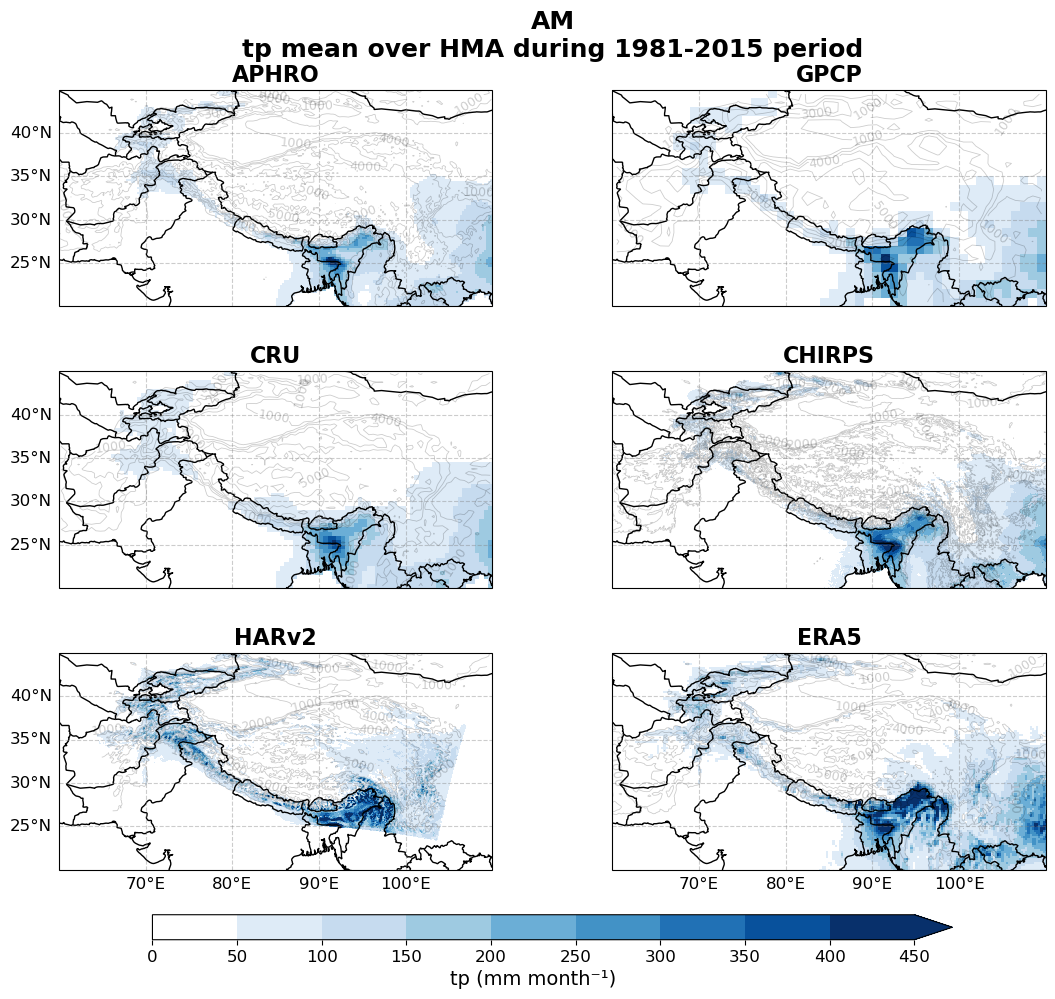

In [43]:
vmax = 500
#vmax = max(np.ceil(float(np.nanmax(np.abs(ds)))) for ds in tp_mean_dict.values())
print(vmax)
levels = np.arange(0, vmax, 50)
base_cmap = plt.get_cmap("Blues", len(levels)-1)
colors = base_cmap(np.arange(base_cmap.N))
colors[0] = [1, 1, 1, 1]  # blanc RGBA
cmap = mcolors.ListedColormap(colors)
norm = mcolors.BoundaryNorm(levels, ncolors=cmap.N)

fig, axes = plt.subplots(3, 2, figsize=(16, 10), subplot_kw={'projection': ccrs.PlateCarree()})
axes = axes.flatten()

for i, ax in enumerate(axes):
    model = models[i]
    data_model = tp_season_dict[model]

    im = ax.pcolormesh(data_model['lon'],data_model['lat'],data_model,transform=ccrs.PlateCarree(),cmap=cmap,norm=norm,shading="auto")

    ax.set_extent([lonW,lonE,latS,latN], crs=ccrs.PlateCarree())
    
    ax.add_feature(cfeature.COASTLINE, linewidth=1)
    ax.add_feature(cfeature.BORDERS, linestyle="-")

    SH = ax.contour(field_SH_dict[model].lon,field_SH_dict[model].lat,field_SH_dict[model],levels=[1000,2000,3000,4000,5000,6000,7000],
                colors="k",linewidths=0.6,alpha=0.2,transform=ccrs.PlateCarree())
    ax.clabel(SH, inline=True, fontsize=9, fmt="%d")
    
    ax.set_title(model, fontsize=16, weight="bold")

    gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True,linewidth=0.8,color="gray",alpha=0.4,linestyle="--")
    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = (i % 2 == 0)
    gl.bottom_labels = (i >= 4) 
    gl.xlabel_style = {"size": 12}
    gl.ylabel_style = {"size": 12}

cbar_ax = fig.add_axes([0.25, 0.05, 0.5, 0.025])
cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal", extend='max')
cbar.set_label("tp (mm month⁻¹)", fontsize=14)
cbar.ax.tick_params(labelsize=12)

fig.subplots_adjust(left=0.08, right=0.92, top=0.90, bottom=0.12, wspace=-0.3, hspace=0.3)
plt.suptitle(f"{season}\ntp mean over HMA during {iyear}-{fyear} period", fontsize=18, weight="bold")

plt.show()

# JJAS

In [44]:
# Run compute_tp_datasets_spatial_mean_season.py

season = 'JJAS'

model1='APHRO'
tp_season1 = xr.open_dataset(f'/bettik/PROJECTS/pr-regional-climate/bricej/results/climbas/spatial_mean_tp_{season}_{dom}_{iyear}-{fyear}_{model1}.nc')['tp']

model2='GPCP'
tp_season2 = xr.open_dataset(f'/bettik/PROJECTS/pr-regional-climate/bricej/results/climbas/spatial_mean_tp_{season}_{dom}_{iyear}-{fyear}_{model2}.nc')['tp']

model3='CRU'
tp_season3 = xr.open_dataset(f'/bettik/PROJECTS/pr-regional-climate/bricej/results/climbas/spatial_mean_tp_{season}_{dom}_{iyear}-{fyear}_{model3}.nc')['tp']

model4='CHIRPS'
tp_season4 = xr.open_dataset(f'/bettik/PROJECTS/pr-regional-climate/bricej/results/climbas/spatial_mean_tp_{season}_{dom}_{iyear}-{fyear}_{model4}.nc')['tp']

model5='HARv2'
tp_season5 = xr.open_dataset(f'/bettik/PROJECTS/pr-regional-climate/bricej/results/climbas/spatial_mean_tp_{season}_{dom}_{iyear}-{fyear}_{model5}.nc')['tp']

model6='ERA5'
tp_season6 = xr.open_dataset(f'/bettik/PROJECTS/pr-regional-climate/bricej/results/climbas/spatial_mean_tp_{season}_{dom}_{iyear}-{fyear}_{model6}.nc')['tp']

tp_season_dict = {
    models[0]: tp_season1,
    models[1]: tp_season2,
    models[2]: tp_season3,
    models[3]: tp_season4,
    models[4]: tp_season5,
    models[5]: tp_season6}

field_SH_dict = {
    models[0]: field1_SH,
    models[1]: field2_SH,
    models[2]: field3_SH,
    models[3]: field4_SH,
    models[4]: field5_SH,
    models[5]: field6_SH}

900


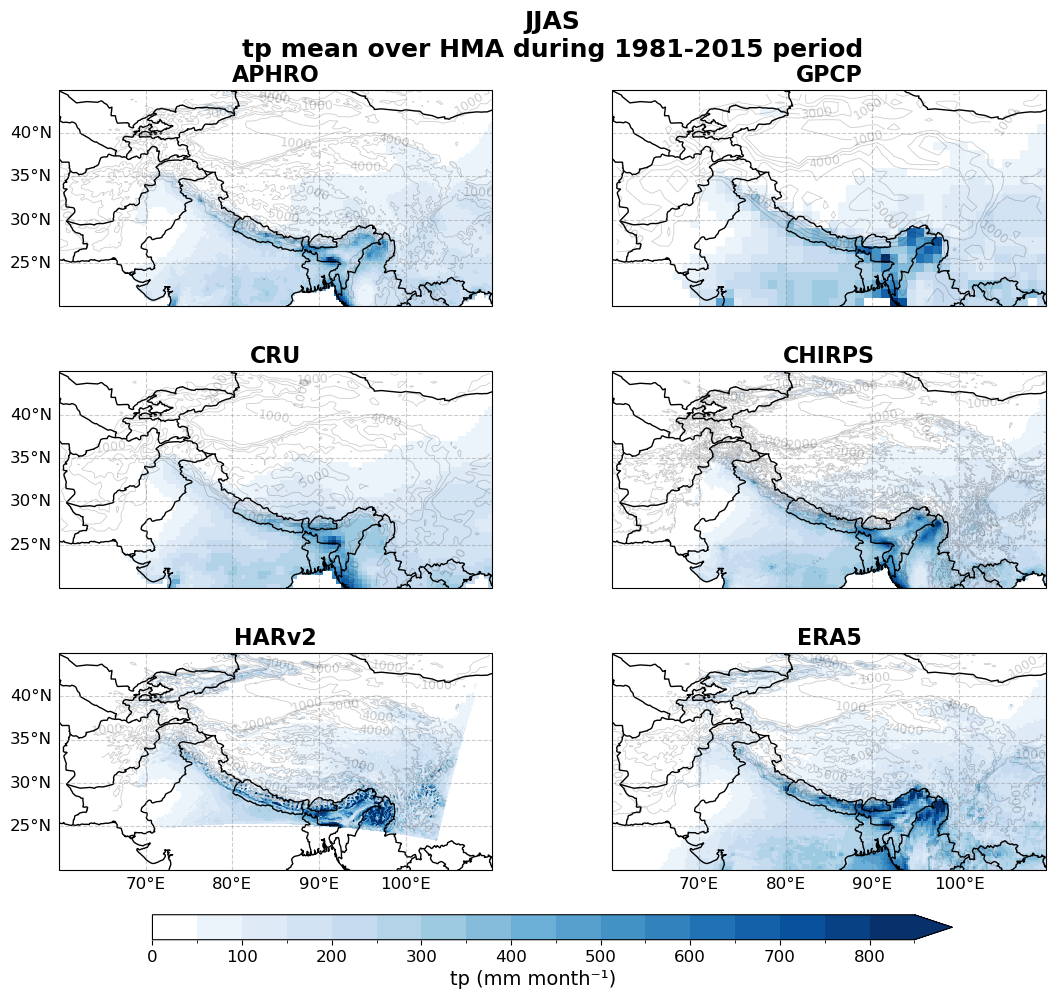

In [45]:
vmax = 900
#vmax = max(np.ceil(float(np.nanmax(np.abs(ds)))) for ds in tp_mean_dict.values())
print(vmax)
levels = np.arange(0, vmax, 50)
base_cmap = plt.get_cmap("Blues", len(levels)-1)
colors = base_cmap(np.arange(base_cmap.N))
colors[0] = [1, 1, 1, 1]  # blanc RGBA
cmap = mcolors.ListedColormap(colors)
norm = mcolors.BoundaryNorm(levels, ncolors=cmap.N)

fig, axes = plt.subplots(3, 2, figsize=(16, 10), subplot_kw={'projection': ccrs.PlateCarree()})
axes = axes.flatten()

for i, ax in enumerate(axes):
    model = models[i]
    data_model = tp_season_dict[model]

    im = ax.pcolormesh(data_model['lon'],data_model['lat'],data_model,transform=ccrs.PlateCarree(),cmap=cmap,norm=norm,shading="auto")

    ax.set_extent([lonW,lonE,latS,latN], crs=ccrs.PlateCarree())
    
    ax.add_feature(cfeature.COASTLINE, linewidth=1)
    ax.add_feature(cfeature.BORDERS, linestyle="-")

    SH = ax.contour(field_SH_dict[model].lon,field_SH_dict[model].lat,field_SH_dict[model],levels=[1000,2000,3000,4000,5000,6000,7000],
                colors="k",linewidths=0.6,alpha=0.2,transform=ccrs.PlateCarree())
    ax.clabel(SH, inline=True, fontsize=9, fmt="%d")
    
    ax.set_title(model, fontsize=16, weight="bold")

    gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True,linewidth=0.8,color="gray",alpha=0.4,linestyle="--")
    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = (i % 2 == 0)
    gl.bottom_labels = (i >= 4) 
    gl.xlabel_style = {"size": 12}
    gl.ylabel_style = {"size": 12}

cbar_ax = fig.add_axes([0.25, 0.05, 0.5, 0.025])
cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal", extend='max')
cbar.set_label("tp (mm month⁻¹)", fontsize=14)
cbar.ax.tick_params(labelsize=12)

fig.subplots_adjust(left=0.08, right=0.92, top=0.90, bottom=0.12, wspace=-0.3, hspace=0.3)
plt.suptitle(f"{season}\ntp mean over HMA during {iyear}-{fyear} period", fontsize=18, weight="bold")

plt.show()

# ON

In [46]:
# Run compute_tp_datasets_spatial_mean_season.py

season = 'ON'

model1='APHRO'
tp_season1 = xr.open_dataset(f'/bettik/PROJECTS/pr-regional-climate/bricej/results/climbas/spatial_mean_tp_{season}_{dom}_{iyear}-{fyear}_{model1}.nc')['tp']

model2='GPCP'
tp_season2 = xr.open_dataset(f'/bettik/PROJECTS/pr-regional-climate/bricej/results/climbas/spatial_mean_tp_{season}_{dom}_{iyear}-{fyear}_{model2}.nc')['tp']

model3='CRU'
tp_season3 = xr.open_dataset(f'/bettik/PROJECTS/pr-regional-climate/bricej/results/climbas/spatial_mean_tp_{season}_{dom}_{iyear}-{fyear}_{model3}.nc')['tp']

model4='CHIRPS'
tp_season4 = xr.open_dataset(f'/bettik/PROJECTS/pr-regional-climate/bricej/results/climbas/spatial_mean_tp_{season}_{dom}_{iyear}-{fyear}_{model4}.nc')['tp']

model5='HARv2'
tp_season5 = xr.open_dataset(f'/bettik/PROJECTS/pr-regional-climate/bricej/results/climbas/spatial_mean_tp_{season}_{dom}_{iyear}-{fyear}_{model5}.nc')['tp']

model6='ERA5'
tp_season6 = xr.open_dataset(f'/bettik/PROJECTS/pr-regional-climate/bricej/results/climbas/spatial_mean_tp_{season}_{dom}_{iyear}-{fyear}_{model6}.nc')['tp']

tp_season_dict = {
    models[0]: tp_season1,
    models[1]: tp_season2,
    models[2]: tp_season3,
    models[3]: tp_season4,
    models[4]: tp_season5,
    models[5]: tp_season6}

field_SH_dict = {
    models[0]: field1_SH,
    models[1]: field2_SH,
    models[2]: field3_SH,
    models[3]: field4_SH,
    models[4]: field5_SH,
    models[5]: field6_SH}

275


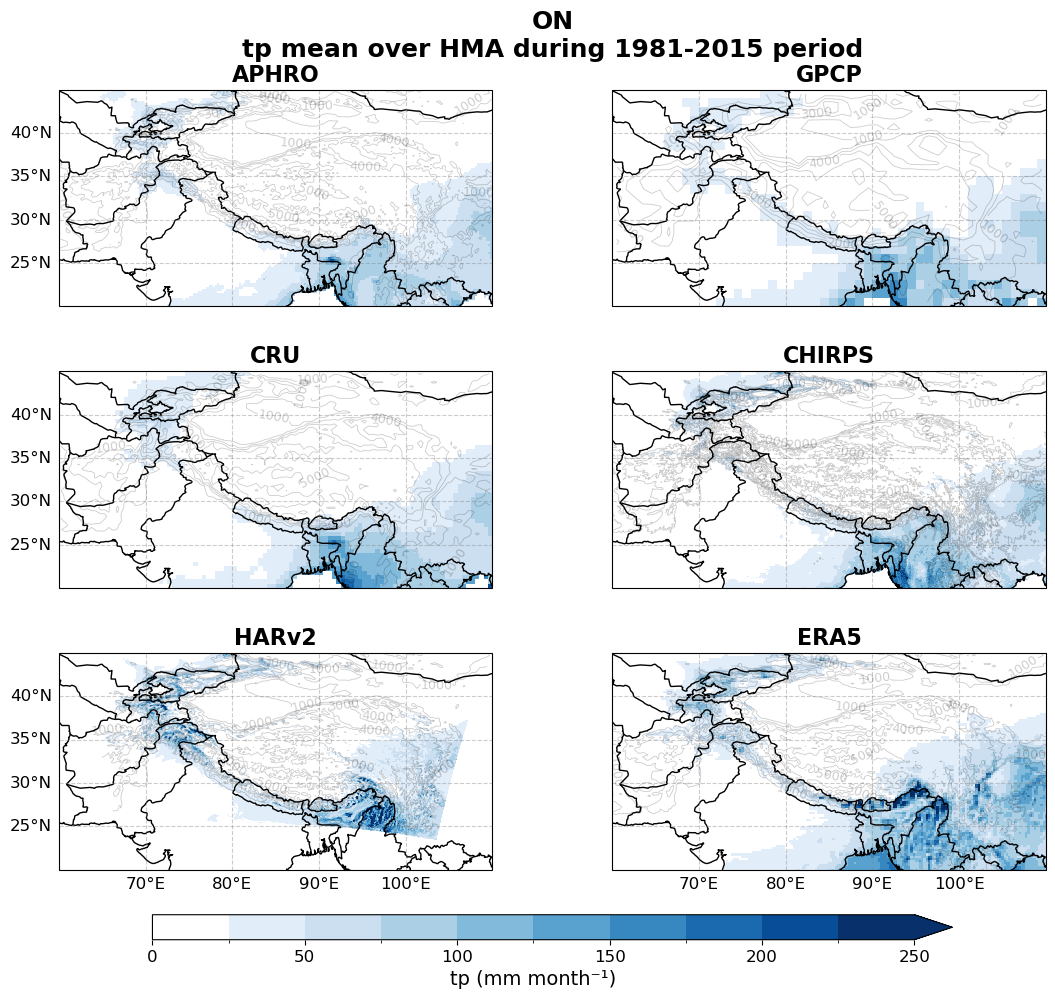

In [47]:
vmax = 275
#vmax = max(np.ceil(float(np.nanmax(np.abs(ds)))) for ds in tp_mean_dict.values())
print(vmax)
levels = np.arange(0, vmax, 25)
base_cmap = plt.get_cmap("Blues", len(levels)-1)
colors = base_cmap(np.arange(base_cmap.N))
colors[0] = [1, 1, 1, 1]  # blanc RGBA
cmap = mcolors.ListedColormap(colors)
norm = mcolors.BoundaryNorm(levels, ncolors=cmap.N)

fig, axes = plt.subplots(3, 2, figsize=(16, 10), subplot_kw={'projection': ccrs.PlateCarree()})
axes = axes.flatten()

for i, ax in enumerate(axes):
    model = models[i]
    data_model = tp_season_dict[model]

    im = ax.pcolormesh(data_model['lon'],data_model['lat'],data_model,transform=ccrs.PlateCarree(),cmap=cmap,norm=norm,shading="auto")

    ax.set_extent([lonW,lonE,latS,latN], crs=ccrs.PlateCarree())
    
    ax.add_feature(cfeature.COASTLINE, linewidth=1)
    ax.add_feature(cfeature.BORDERS, linestyle="-")

    SH = ax.contour(field_SH_dict[model].lon,field_SH_dict[model].lat,field_SH_dict[model],levels=[1000,2000,3000,4000,5000,6000,7000],
                colors="k",linewidths=0.6,alpha=0.2,transform=ccrs.PlateCarree())
    ax.clabel(SH, inline=True, fontsize=9, fmt="%d")
    
    ax.set_title(model, fontsize=16, weight="bold")

    gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True,linewidth=0.8,color="gray",alpha=0.4,linestyle="--")
    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = (i % 2 == 0)
    gl.bottom_labels = (i >= 4) 
    gl.xlabel_style = {"size": 12}
    gl.ylabel_style = {"size": 12}

cbar_ax = fig.add_axes([0.25, 0.05, 0.5, 0.025])
cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal", extend='max')
cbar.set_label("tp (mm month⁻¹)", fontsize=14)
cbar.ax.tick_params(labelsize=12)

fig.subplots_adjust(left=0.08, right=0.92, top=0.90, bottom=0.12, wspace=-0.3, hspace=0.3)
plt.suptitle(f"{season}\ntp mean over HMA during {iyear}-{fyear} period", fontsize=18, weight="bold")

plt.show()

# Annual Trend

In [23]:
# Run compute_tp_datasets_spatial_trend_annual.py

model1 = 'APHRO'
par1 = xr.open_dataset(f'/bettik/PROJECTS/pr-regional-climate/bricej/results/climbas/spatial_trend_tp_annual_{dom}_{iyear}-{fyear}_{model1}.nc')

model2 = 'GPCP'
par2 = xr.open_dataset(f'/bettik/PROJECTS/pr-regional-climate/bricej/results/climbas/spatial_trend_tp_annual_{dom}_{iyear}-{fyear}_{model2}.nc')

model3 = 'CRU'
par3 = xr.open_dataset(f'/bettik/PROJECTS/pr-regional-climate/bricej/results/climbas/spatial_trend_tp_annual_{dom}_{iyear}-{fyear}_{model3}.nc')

model4 = 'CHIRPS'
par4 = xr.open_dataset(f'/bettik/PROJECTS/pr-regional-climate/bricej/results/climbas/spatial_trend_tp_annual_{dom}_{iyear}-{fyear}_{model4}.nc')

model5 = 'HARv2'
par5 = xr.open_dataset(f'/bettik/PROJECTS/pr-regional-climate/bricej/results/climbas/spatial_trend_tp_annual_{dom}_{iyear}-{fyear}_{model5}.nc')

model6 = 'ERA5'
par6 = xr.open_dataset(f'/bettik/PROJECTS/pr-regional-climate/bricej/results/climbas/spatial_trend_tp_annual_{dom}_{iyear}-{fyear}_{model6}.nc')


In [30]:
trend_annual_dict={}
p_annual_dict={}

trend1 = par1['trend'];p1 = par1['pvalue']
trend_annual_dict[models[0]] = trend1
p_annual_dict[models[0]] = p1

trend2 = par2['trend'];p2 = par2['pvalue']
trend_annual_dict[models[1]] = trend2
p_annual_dict[models[1]] = p2

trend3 = par3['trend'];p3 = par3['pvalue']
trend_annual_dict[models[2]] = trend3
p_annual_dict[models[2]] = p3

trend4 = par4['trend'];p4 = par4['pvalue']
trend_annual_dict[models[3]] = trend4
p_annual_dict[models[3]] = p4

trend5 = par5['trend'];p5 = par5['pvalue']
trend_annual_dict[models[4]] = trend5
p_annual_dict[models[4]] = p5

trend6 = par6['trend'];p6 = par6['pvalue']
trend_annual_dict[models[5]] = trend6
p_annual_dict[models[5]] = p6

5


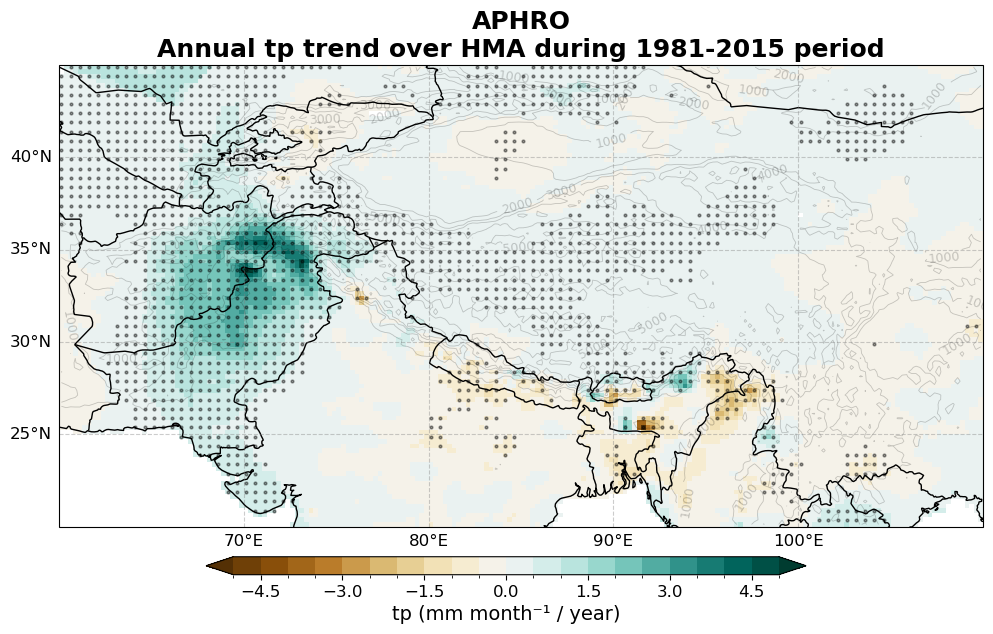

In [31]:
step = 0.5
vmax = 5
#vmax = max(np.round(float(np.nanmax(np.abs(ds))), 1) for ds in trend_annual_dict.values())
print(vmax)
levels = np.linspace(-vmax, vmax, int(2*vmax/step)+1)
cmap = plt.get_cmap("BrBG", len(levels)-1+2)
norm = mcolors.BoundaryNorm(levels, ncolors=cmap.N, extend='both')

fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(12,6))

model = models[0]
data_model = trend_annual_dict[model]

pcm = ax.pcolormesh(data_model['lon'],data_model['lat'],data_model,transform=ccrs.PlateCarree(),cmap=cmap,norm=norm,shading="auto")

sig = p_annual_dict[model] < 0.05 
step = 2
lon_sig, lat_sig = data_model['lon'].values, data_model['lat'].values
lon_grid, lat_grid = np.meshgrid(lon_sig, lat_sig)
ax.scatter(lon_grid[::step, ::step][np.where(sig[::step, ::step])],lat_grid[::step, ::step][np.where(sig[::step, ::step])],
           color='black', s=4, marker='o', transform=ccrs.PlateCarree(), zorder=5, alpha=0.4)
    
ax.set_extent([lonW,lonE,latS,latN], crs=ccrs.PlateCarree())
    
ax.add_feature(cfeature.COASTLINE, linewidth=1)
ax.add_feature(cfeature.BORDERS, linestyle="-")

SH = ax.contour(field_SH_dict[model].lon,field_SH_dict[model].lat,field_SH_dict[model],levels=[1000,2000,3000,4000,5000,6000,7000],
                colors="k",linewidths=0.6,alpha=0.2,transform=ccrs.PlateCarree())
ax.clabel(SH, inline=True, fontsize=9, fmt="%d")
    
ax.set_title(model, fontsize=16, weight="bold")

gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True,linewidth=0.8,color="gray",alpha=0.4,linestyle="--")
gl.top_labels = False
gl.right_labels = False
gl.left_labels = True
gl.bottom_labels = True
gl.xlabel_style = {"size": 12}
gl.ylabel_style = {"size": 12}

cbar_ax = fig.add_axes([0.25, 0.03, 0.5, 0.03])
cbar = fig.colorbar(pcm, cax=cbar_ax, orientation="horizontal", extend='both')
cbar.set_label("tp (mm month⁻¹ / year)", fontsize=14)
cbar.ax.tick_params(labelsize=12)

ax.set_title(f"APHRO\nAnnual tp trend over HMA during {iyear}-{fyear} period", fontsize=18, weight="bold")

plt.show()

5


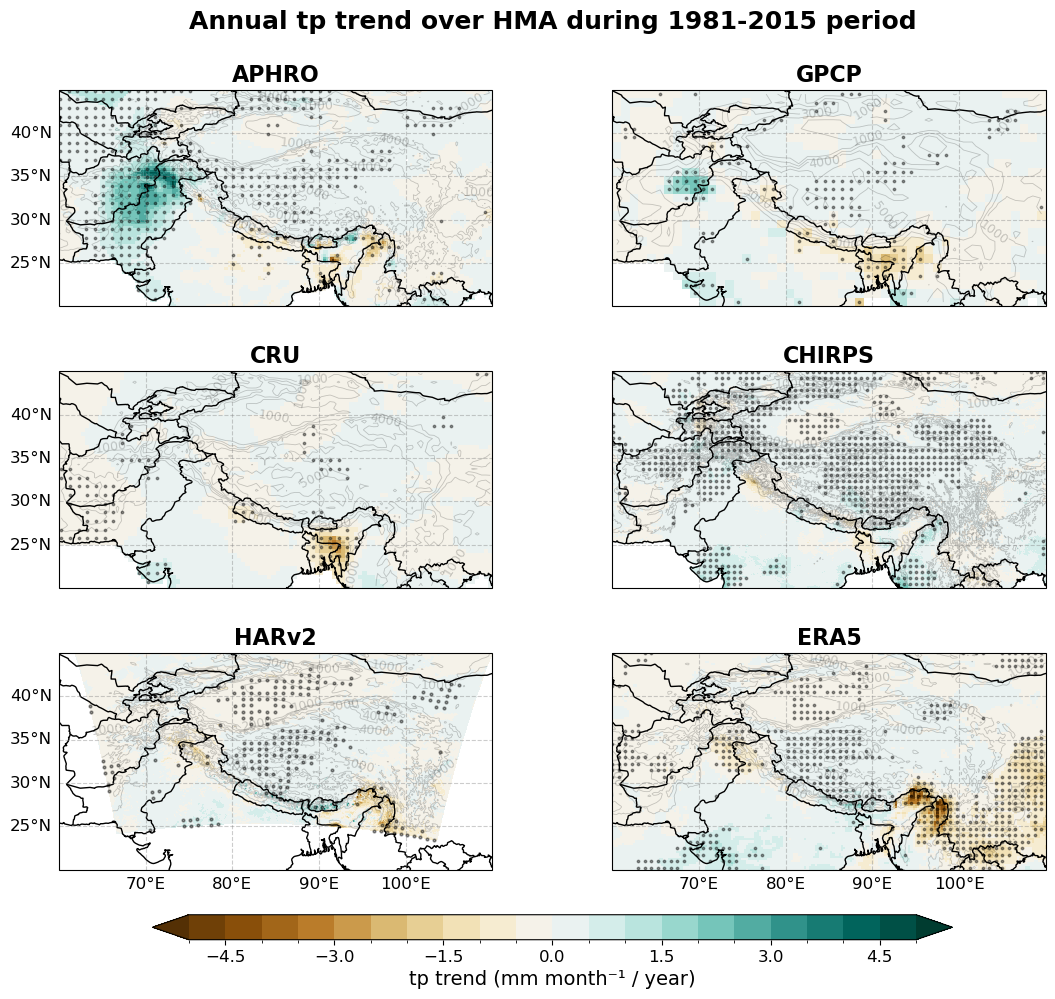

In [33]:
step_p = {
    models[0]: 4,
    models[1]: 1,
    models[2]: 2,
    models[3]: 14,
    models[4]: 8,
    models[5]: 3}

step = 0.5
vmax = 5
#vmax = max(np.round(float(np.nanmax(np.abs(ds))), 1) for ds in trend_annual_dict.values())
print(vmax)
levels = np.linspace(-vmax, vmax, int(2*vmax/step)+1)
cmap = plt.get_cmap("BrBG", len(levels)-1+2)
norm = mcolors.BoundaryNorm(levels, ncolors=cmap.N, extend='both')

fig, axes = plt.subplots(3, 2, figsize=(16, 10), subplot_kw={'projection': ccrs.PlateCarree()})
axes = axes.flatten()

for i, (ax, model) in enumerate(zip(axes, models)):
    #model = models[i]
    data_model = trend_annual_dict[model]

    im = ax.pcolormesh(data_model['lon'],data_model['lat'],data_model,transform=ccrs.PlateCarree(),cmap=cmap,norm=norm,shading="auto")

    sig = p_annual_dict[model] < 0.05 
    step = step_p[model]
    if model == 'HARv2':
        lon2d = data_model['lon'].values
        lat2d = data_model['lat'].values
        mask = sig.values
        ax.scatter(lon2d[::step, ::step][mask[::step, ::step]],lat2d[::step, ::step][mask[::step, ::step]],
                    color='black',s=4,marker='o',transform=ccrs.PlateCarree(),zorder=5,alpha=0.4)
    else:
        lon_sig, lat_sig = data_model['lon'].values, data_model['lat'].values
        lon_grid, lat_grid = np.meshgrid(lon_sig, lat_sig)
        ax.scatter(lon_grid[::step, ::step][np.where(sig[::step, ::step])],lat_grid[::step, ::step][np.where(sig[::step, ::step])],
               color='black', s=3, marker='o', transform=ccrs.PlateCarree(), zorder=5, alpha=0.4)
    
    ax.set_extent([lonW,lonE,latS,latN], crs=ccrs.PlateCarree())
    
    ax.add_feature(cfeature.COASTLINE, linewidth=1)
    ax.add_feature(cfeature.BORDERS, linestyle="-")

    SH = ax.contour(field_SH_dict[model].lon,field_SH_dict[model].lat,field_SH_dict[model],levels=[1000,2000,3000,4000,5000,6000,7000],
                colors="k",linewidths=0.6,alpha=0.2,transform=ccrs.PlateCarree())
    ax.clabel(SH, inline=True, fontsize=9, fmt="%d")
    
    ax.set_title(model, fontsize=16, weight="bold")

    gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True,linewidth=0.8,color="gray",alpha=0.4,linestyle="--")
    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = (i % 2 == 0)
    gl.bottom_labels = (i >= 4) 
    gl.xlabel_style = {"size": 12}
    gl.ylabel_style = {"size": 12}

# Supprimer les axes inutilisés
#for j in range(len(models), len(axes)):
#    fig.delaxes(axes[j])
    
cbar_ax = fig.add_axes([0.25, 0.05, 0.5, 0.025])
cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal", extend='both')
cbar.set_label("tp trend (mm month⁻¹ / year)", fontsize=14)
cbar.ax.tick_params(labelsize=12)

fig.subplots_adjust(left=0.08, right=0.92, top=0.90, bottom=0.12, wspace=-0.3, hspace=0.3)
plt.suptitle(f"Annual tp trend over HMA during {iyear}-{fyear} period", fontsize=18, weight="bold")

plt.show()

# Seasonal Trend

# DJFM

In [15]:
# Run : python compute_tp_datasets_spatial_trend_season.py 1981 2025 HMA [12,1,2,3]

season='DJFM'

trend_seasonal_dict={}
p_seasonal_dict={}

model1='APHRO'
par1 = xr.open_dataset(f'/bettik/PROJECTS/pr-regional-climate/bricej/results/climbas/spatial_trend_tp_{season}_{dom}_{iyear}-{fyear}_{model1}.nc')
trend1 = par1['trend'];p1 = par1['pvalue']
trend_seasonal_dict[models[0]] = trend1
p_seasonal_dict[models[0]] = p1

model2='GPCP'
par2 = xr.open_dataset(f'/bettik/PROJECTS/pr-regional-climate/bricej/results/climbas/spatial_trend_tp_{season}_{dom}_{iyear}-{fyear}_{model2}.nc')
trend2 = par2['trend'];p2 = par2['pvalue']
trend_seasonal_dict[models[1]] = trend2
p_seasonal_dict[models[1]] = p2

model3='CRU'
par3 = xr.open_dataset(f'/bettik/PROJECTS/pr-regional-climate/bricej/results/climbas/spatial_trend_tp_{season}_{dom}_{iyear}-{fyear}_{model3}.nc')
trend3 = par3['trend'];p3 = par3['pvalue']
trend_seasonal_dict[models[2]] = trend3
p_seasonal_dict[models[2]] = p3

model4='CHIRPS'
par4 = xr.open_dataset(f'/bettik/PROJECTS/pr-regional-climate/bricej/results/climbas/spatial_trend_tp_{season}_{dom}_{iyear}-{fyear}_{model4}.nc')
trend4 = par4['trend'];p4 = par4['pvalue']
trend_seasonal_dict[models[3]] = trend4
p_seasonal_dict[models[3]] = p4

model5='HARv2'
par5 = xr.open_dataset(f'/bettik/PROJECTS/pr-regional-climate/bricej/results/climbas/spatial_trend_tp_{season}_{dom}_{iyear}-{fyear}_{model5}.nc')
trend5 = par5['trend'];p5 = par5['pvalue']
trend_seasonal_dict[models[4]] = trend5
p_seasonal_dict[models[4]] = p5

model6='ERA5'
par6 = xr.open_dataset(f'/bettik/PROJECTS/pr-regional-climate/bricej/results/climbas/spatial_trend_tp_{season}_{dom}_{iyear}-{fyear}_{model6}.nc')
trend6 = par6['trend'];p6 = par6['pvalue']
trend_seasonal_dict[models[5]] = trend6
p_seasonal_dict[models[5]] = p6

5


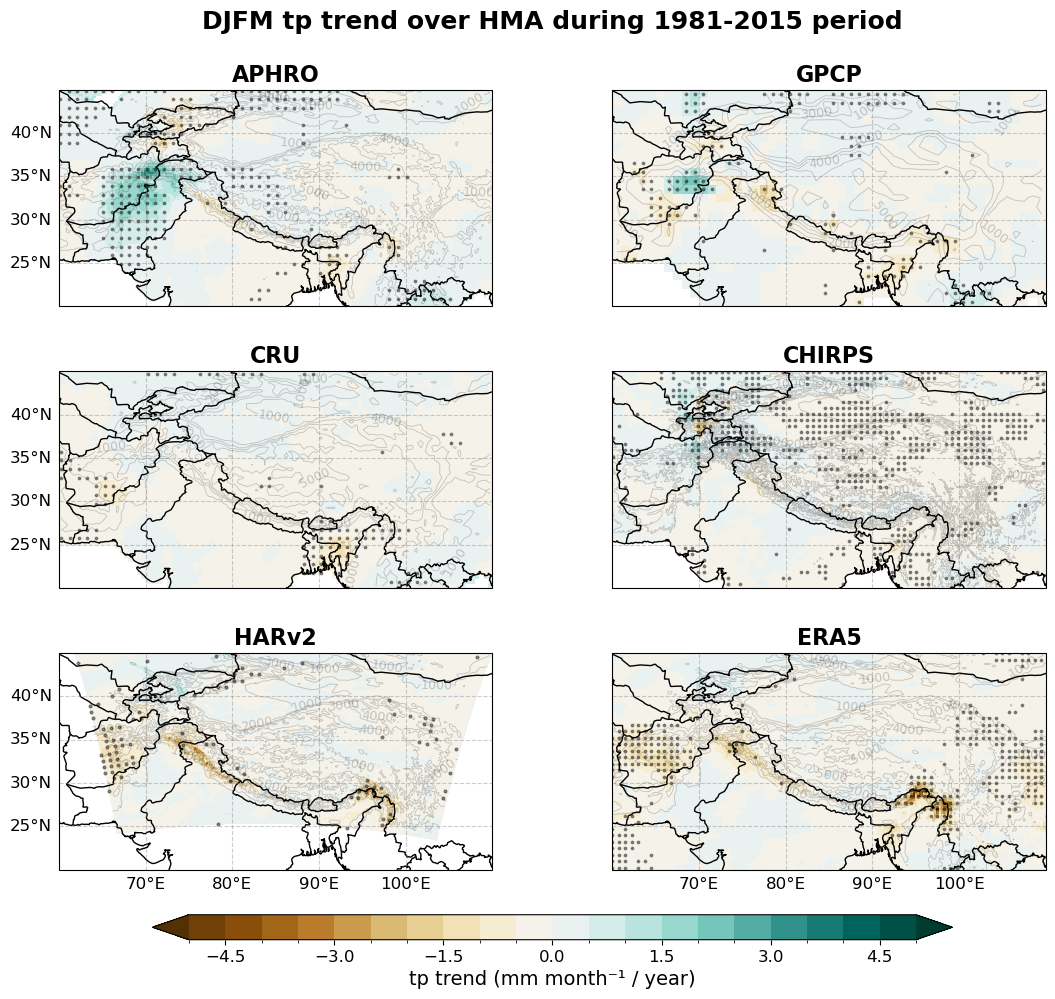

In [18]:
step_p = {
    models[0]: 4,
    models[1]: 1,
    models[2]: 2,
    models[3]: 14,
    models[4]: 8,
    models[5]: 3}

step = 0.5
vmax = 5
#vmax = max(np.round(float(np.nanmax(np.abs(ds))), 1) for ds in trend_annual_dict.values())
print(vmax)
levels = np.linspace(-vmax, vmax, int(2*vmax/step)+1)
cmap = plt.get_cmap("BrBG", len(levels)-1+2)
norm = mcolors.BoundaryNorm(levels, ncolors=cmap.N, extend='both')

fig, axes = plt.subplots(3, 2, figsize=(16, 10), subplot_kw={'projection': ccrs.PlateCarree()})
axes = axes.flatten()

for i, (ax, model) in enumerate(zip(axes, models)):
    #model = models[i]
    data_model = trend_seasonal_dict[model]

    im = ax.pcolormesh(data_model['lon'],data_model['lat'],data_model,transform=ccrs.PlateCarree(),cmap=cmap,norm=norm,shading="auto")

    sig = p_seasonal_dict[model] < 0.05 
    step = step_p[model]
    if model == 'HARv2':
        lon2d = data_model['lon'].values
    
        lat2d = data_model['lat'].values
        mask = sig.values
        ax.scatter(lon2d[::step, ::step][mask[::step, ::step]],lat2d[::step, ::step][mask[::step, ::step]],
                    color='black',s=4,marker='o',transform=ccrs.PlateCarree(),zorder=5,alpha=0.4)
    else:
        lon_sig, lat_sig = data_model['lon'].values, data_model['lat'].values
        lon_grid, lat_grid = np.meshgrid(lon_sig, lat_sig)
        ax.scatter(lon_grid[::step, ::step][np.where(sig[::step, ::step])],lat_grid[::step, ::step][np.where(sig[::step, ::step])],
                   color='black', s=3, marker='o', transform=ccrs.PlateCarree(), zorder=5, alpha=0.4)
    
    ax.set_extent([lonW,lonE,latS,latN], crs=ccrs.PlateCarree())
    
    ax.add_feature(cfeature.COASTLINE, linewidth=1)
    ax.add_feature(cfeature.BORDERS, linestyle="-")

    SH = ax.contour(field_SH_dict[model].lon,field_SH_dict[model].lat,field_SH_dict[model],levels=[1000,2000,3000,4000,5000,6000,7000],
                colors="k",linewidths=0.6,alpha=0.2,transform=ccrs.PlateCarree())
    ax.clabel(SH, inline=True, fontsize=9, fmt="%d")
    
    ax.set_title(model, fontsize=16, weight="bold")

    gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True,linewidth=0.8,color="gray",alpha=0.4,linestyle="--")
    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = (i % 2 == 0)
    gl.bottom_labels = (i >= 4) 
    gl.xlabel_style = {"size": 12}
    gl.ylabel_style = {"size": 12}

# Supprimer les axes inutilisés
#for j in range(len(models), len(axes)):
#    fig.delaxes(axes[j])
    
cbar_ax = fig.add_axes([0.25, 0.05, 0.5, 0.025])
cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal", extend='both')
cbar.set_label("tp trend (mm month⁻¹ / year)", fontsize=14)
cbar.ax.tick_params(labelsize=12)

fig.subplots_adjust(left=0.08, right=0.92, top=0.90, bottom=0.12, wspace=-0.3, hspace=0.3)
plt.suptitle(f"{season} tp trend over HMA during {iyear}-{fyear} period", fontsize=18, weight="bold")

plt.show()

# AM

In [19]:
# Run : python compute_tp_datasets_spatial_trend_season.py 1981 2025 HMA [4,5]

season='AM'

trend_seasonal_dict={}
p_seasonal_dict={}

model1='APHRO'
par1 = xr.open_dataset(f'/bettik/PROJECTS/pr-regional-climate/bricej/results/climbas/spatial_trend_tp_{season}_{dom}_{iyear}-{fyear}_{model1}.nc')
trend1 = par1['trend'];p1 = par1['pvalue']
trend_seasonal_dict[models[0]] = trend1
p_seasonal_dict[models[0]] = p1

model2='GPCP'
par2 = xr.open_dataset(f'/bettik/PROJECTS/pr-regional-climate/bricej/results/climbas/spatial_trend_tp_{season}_{dom}_{iyear}-{fyear}_{model2}.nc')
trend2 = par2['trend'];p2 = par2['pvalue']
trend_seasonal_dict[models[1]] = trend2
p_seasonal_dict[models[1]] = p2

model3='CRU'
par3 = xr.open_dataset(f'/bettik/PROJECTS/pr-regional-climate/bricej/results/climbas/spatial_trend_tp_{season}_{dom}_{iyear}-{fyear}_{model3}.nc')
trend3 = par3['trend'];p3 = par3['pvalue']
trend_seasonal_dict[models[2]] = trend3
p_seasonal_dict[models[2]] = p3

model4='CHIRPS'
par4 = xr.open_dataset(f'/bettik/PROJECTS/pr-regional-climate/bricej/results/climbas/spatial_trend_tp_{season}_{dom}_{iyear}-{fyear}_{model4}.nc')
trend4 = par4['trend'];p4 = par4['pvalue']
trend_seasonal_dict[models[3]] = trend4
p_seasonal_dict[models[3]] = p4

model5='HARv2'
par5 = xr.open_dataset(f'/bettik/PROJECTS/pr-regional-climate/bricej/results/climbas/spatial_trend_tp_{season}_{dom}_{iyear}-{fyear}_{model5}.nc')
trend5 = par5['trend'];p5 = par5['pvalue']
trend_seasonal_dict[models[4]] = trend5
p_seasonal_dict[models[4]] = p5

model6='ERA5'
par6 = xr.open_dataset(f'/bettik/PROJECTS/pr-regional-climate/bricej/results/climbas/spatial_trend_tp_{season}_{dom}_{iyear}-{fyear}_{model6}.nc')
trend6 = par6['trend'];p6 = par6['pvalue']
trend_seasonal_dict[models[5]] = trend6
p_seasonal_dict[models[5]] = p6

5


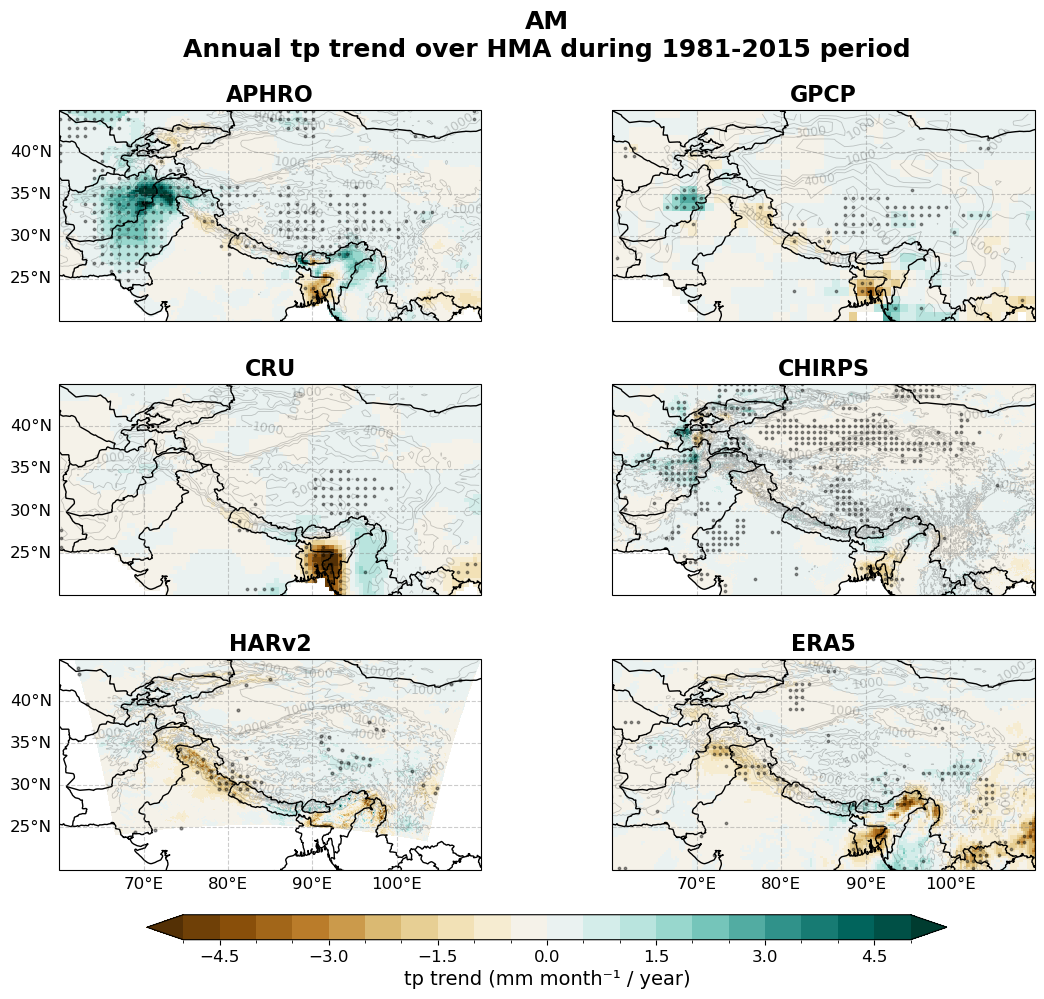

In [21]:
step_p = {
    models[0]: 4,
    models[1]: 1,
    models[2]: 2,
    models[3]: 14,
    models[4]: 8,
    models[5]: 3}

step = 0.5
vmax = 5
#vmax = max(np.round(float(np.nanmax(np.abs(ds))), 1) for ds in trend_annual_dict.values())
print(vmax)
levels = np.linspace(-vmax, vmax, int(2*vmax/step)+1)
cmap = plt.get_cmap("BrBG", len(levels)-1+2)
norm = mcolors.BoundaryNorm(levels, ncolors=cmap.N, extend='both')

fig, axes = plt.subplots(3, 2, figsize=(16, 10), subplot_kw={'projection': ccrs.PlateCarree()})
axes = axes.flatten()

for i, (ax, model) in enumerate(zip(axes, models)):
    #model = models[i]
    data_model = trend_seasonal_dict[model]

    im = ax.pcolormesh(data_model['lon'],data_model['lat'],data_model,transform=ccrs.PlateCarree(),cmap=cmap,norm=norm,shading="auto")

    sig = p_seasonal_dict[model] < 0.05 
    step = step_p[model]
    if model == 'HARv2':
        lon2d = data_model['lon'].values
        lat2d = data_model['lat'].values
        mask = sig.values
        ax.scatter(lon2d[::step, ::step][mask[::step, ::step]],lat2d[::step, ::step][mask[::step, ::step]],
                    color='black',s=4,marker='o',transform=ccrs.PlateCarree(),zorder=5,alpha=0.4)
    else:
        lon_sig, lat_sig = data_model['lon'].values, data_model['lat'].values
        lon_grid, lat_grid = np.meshgrid(lon_sig, lat_sig)
        ax.scatter(lon_grid[::step, ::step][np.where(sig[::step, ::step])],lat_grid[::step, ::step][np.where(sig[::step, ::step])],
               color='black', s=3, marker='o', transform=ccrs.PlateCarree(), zorder=5, alpha=0.4)
    
    ax.set_extent([lonW,lonE,latS,latN], crs=ccrs.PlateCarree())
    
    ax.add_feature(cfeature.COASTLINE, linewidth=1)
    ax.add_feature(cfeature.BORDERS, linestyle="-")

    SH = ax.contour(field_SH_dict[model].lon,field_SH_dict[model].lat,field_SH_dict[model],levels=[1000,2000,3000,4000,5000,6000,7000],
                colors="k",linewidths=0.6,alpha=0.2,transform=ccrs.PlateCarree())
    ax.clabel(SH, inline=True, fontsize=9, fmt="%d")
    
    ax.set_title(model, fontsize=16, weight="bold")

    gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True,linewidth=0.8,color="gray",alpha=0.4,linestyle="--")
    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = (i % 2 == 0)
    gl.bottom_labels = (i >= 4) 
    gl.xlabel_style = {"size": 12}
    gl.ylabel_style = {"size": 12}

# Supprimer les axes inutilisés
for j in range(len(models), len(axes)):
    fig.delaxes(axes[j])
    
cbar_ax = fig.add_axes([0.25, 0.05, 0.5, 0.025])
cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal", extend='both')
cbar.set_label("tp trend (mm month⁻¹ / year)", fontsize=14)
cbar.ax.tick_params(labelsize=12)

fig.subplots_adjust(left=0.08, right=0.92, top=0.88, bottom=0.12, wspace=-0.3, hspace=0.3)
plt.suptitle(f"{season}\nAnnual tp trend over HMA during {iyear}-{fyear} period", fontsize=18, weight="bold")

plt.show()

# JJAS

In [1]:
# Run : python compute_tp_datasets_spatial_trend_season.py 1981 2025 HMA [6,7,8,9]

season='JJAS'

trend_seasonal_dict={}
p_seasonal_dict={}

model1='APHRO'
par1 = xr.open_dataset(f'/bettik/PROJECTS/pr-regional-climate/bricej/results/climbas/spatial_trend_tp_{season}_{dom}_{iyear}-{fyear}_{model1}.nc')
trend1 = par1['trend'];p1 = par1['pvalue']
trend_seasonal_dict[models[0]] = trend1
p_seasonal_dict[models[0]] = p1

model2='GPCP'
par2 = xr.open_dataset(f'/bettik/PROJECTS/pr-regional-climate/bricej/results/climbas/spatial_trend_tp_{season}_{dom}_{iyear}-{fyear}_{model2}.nc')
trend2 = par2['trend'];p2 = par2['pvalue']
trend_seasonal_dict[models[1]] = trend2
p_seasonal_dict[models[1]] = p2

model3='CRU'
par3 = xr.open_dataset(f'/bettik/PROJECTS/pr-regional-climate/bricej/results/climbas/spatial_trend_tp_{season}_{dom}_{iyear}-{fyear}_{model3}.nc')
trend3 = par3['trend'];p3 = par3['pvalue']
trend_seasonal_dict[models[2]] = trend3
p_seasonal_dict[models[2]] = p3

model4='CHIRPS'
par4 = xr.open_dataset(f'/bettik/PROJECTS/pr-regional-climate/bricej/results/climbas/spatial_trend_tp_{season}_{dom}_{iyear}-{fyear}_{model4}.nc')
trend4 = par4['trend'];p4 = par4['pvalue']
trend_seasonal_dict[models[3]] = trend4
p_seasonal_dict[models[3]] = p4

model5='HARv2'
par5 = xr.open_dataset(f'/bettik/PROJECTS/pr-regional-climate/bricej/results/climbas/spatial_trend_tp_{season}_{dom}_{iyear}-{fyear}_{model5}.nc')
trend5 = par5['trend'];p5 = par5['pvalue']
trend_seasonal_dict[models[4]] = trend5
p_seasonal_dict[models[4]] = p5

model6='ERA5'
par6 = xr.open_dataset(f'/bettik/PROJECTS/pr-regional-climate/bricej/results/climbas/spatial_trend_tp_{season}_{dom}_{iyear}-{fyear}_{model6}.nc')
trend6 = par6['trend'];p6 = par6['pvalue']
trend_seasonal_dict[models[5]] = trend6
p_seasonal_dict[models[5]] = p6

NameError: name 'xr' is not defined

5


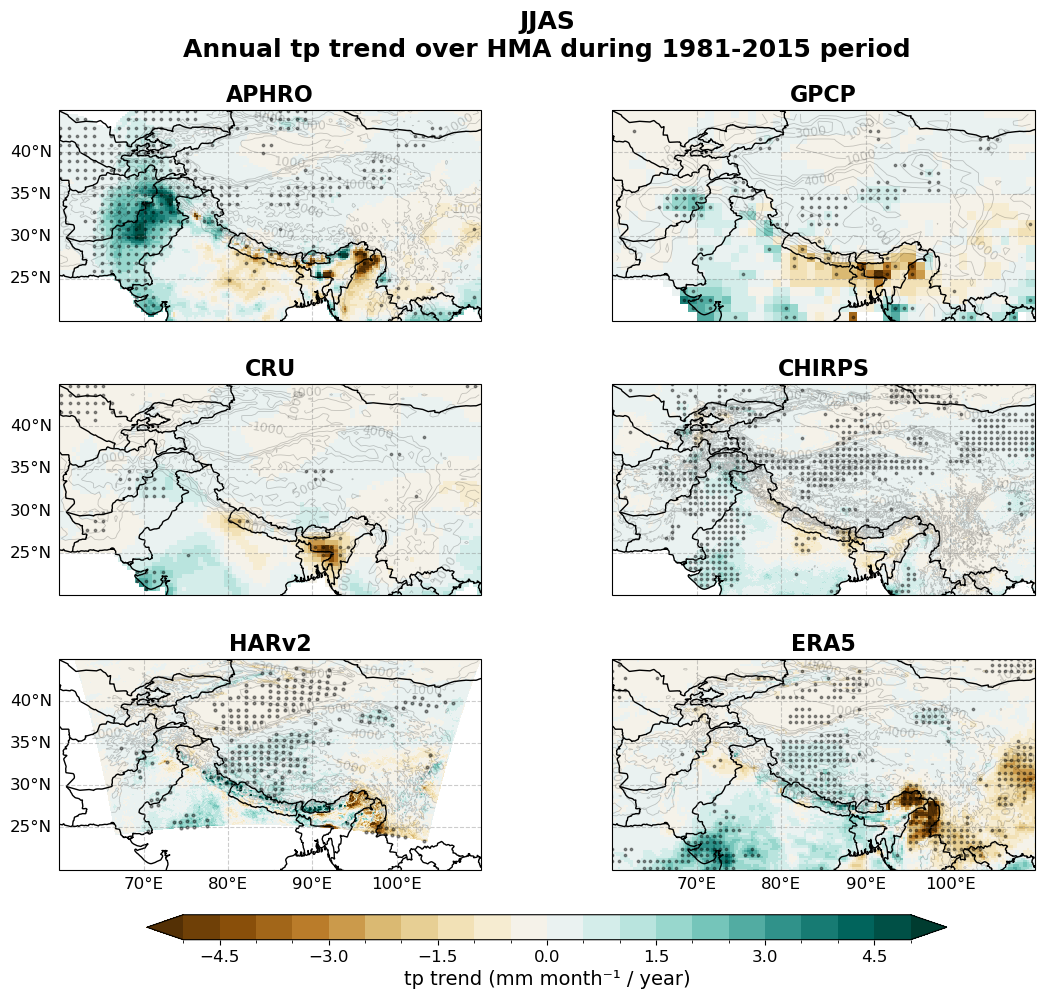

In [23]:
step_p = {
    models[0]: 4,
    models[1]: 1,
    models[2]: 2,
    models[3]: 14,
    models[4]: 8,
    models[5]: 3}

step = 0.5
vmax = 5
#vmax = max(np.round(float(np.nanmax(np.abs(ds))), 1) for ds in trend_annual_dict.values())
print(vmax)
levels = np.linspace(-vmax, vmax, int(2*vmax/step)+1)
cmap = plt.get_cmap("BrBG", len(levels)-1+2)
norm = mcolors.BoundaryNorm(levels, ncolors=cmap.N, extend='both')

fig, axes = plt.subplots(3, 2, figsize=(16, 10), subplot_kw={'projection': ccrs.PlateCarree()})
axes = axes.flatten()

for i, (ax, model) in enumerate(zip(axes, models)):
    #model = models[i]
    data_model = trend_seasonal_dict[model]

    im = ax.pcolormesh(data_model['lon'],data_model['lat'],data_model,transform=ccrs.PlateCarree(),cmap=cmap,norm=norm,shading="auto")

    sig = p_seasonal_dict[model] < 0.05 
    step = step_p[model]
    if model == 'HARv2':
        lon2d = data_model['lon'].values
        lat2d = data_model['lat'].values
        mask = sig.values
        ax.scatter(lon2d[::step, ::step][mask[::step, ::step]],lat2d[::step, ::step][mask[::step, ::step]],
                    color='black',s=4,marker='o',transform=ccrs.PlateCarree(),zorder=5,alpha=0.4)
    else:
        lon_sig, lat_sig = data_model['lon'].values, data_model['lat'].values
        lon_grid, lat_grid = np.meshgrid(lon_sig, lat_sig)
        ax.scatter(lon_grid[::step, ::step][np.where(sig[::step, ::step])],lat_grid[::step, ::step][np.where(sig[::step, ::step])],
               color='black', s=3, marker='o', transform=ccrs.PlateCarree(), zorder=5, alpha=0.4)
    
    ax.set_extent([lonW,lonE,latS,latN], crs=ccrs.PlateCarree())
    
    ax.add_feature(cfeature.COASTLINE, linewidth=1)
    ax.add_feature(cfeature.BORDERS, linestyle="-")

    SH = ax.contour(field_SH_dict[model].lon,field_SH_dict[model].lat,field_SH_dict[model],levels=[1000,2000,3000,4000,5000,6000,7000],
                colors="k",linewidths=0.6,alpha=0.2,transform=ccrs.PlateCarree())
    ax.clabel(SH, inline=True, fontsize=9, fmt="%d")
    
    ax.set_title(model, fontsize=16, weight="bold")

    gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True,linewidth=0.8,color="gray",alpha=0.4,linestyle="--")
    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = (i % 2 == 0)
    gl.bottom_labels = (i >= 4) 
    gl.xlabel_style = {"size": 12}
    gl.ylabel_style = {"size": 12}

# Supprimer les axes inutilisés
for j in range(len(models), len(axes)):
    fig.delaxes(axes[j])
    
cbar_ax = fig.add_axes([0.25, 0.05, 0.5, 0.025])
cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal", extend='both')
cbar.set_label("tp trend (mm month⁻¹ / year)", fontsize=14)
cbar.ax.tick_params(labelsize=12)

fig.subplots_adjust(left=0.08, right=0.92, top=0.88, bottom=0.12, wspace=-0.3, hspace=0.3)
plt.suptitle(f"{season}\nAnnual tp trend over HMA during {iyear}-{fyear} period", fontsize=18, weight="bold")

plt.show()

# ON

In [25]:
# Run : python compute_tp_datasets_spatial_trend_season.py 1981 2025 HMA [10,11]

season='ON'

trend_seasonal_dict={}
p_seasonal_dict={}

model1='APHRO'
par1 = xr.open_dataset(f'/bettik/PROJECTS/pr-regional-climate/bricej/results/climbas/spatial_trend_tp_{season}_{dom}_{iyear}-{fyear}_{model1}.nc')
trend1 = par1['trend'];p1 = par1['pvalue']
trend_seasonal_dict[models[0]] = trend1
p_seasonal_dict[models[0]] = p1

model2='GPCP'
par2 = xr.open_dataset(f'/bettik/PROJECTS/pr-regional-climate/bricej/results/climbas/spatial_trend_tp_{season}_{dom}_{iyear}-{fyear}_{model2}.nc')
trend2 = par2['trend'];p2 = par2['pvalue']
trend_seasonal_dict[models[1]] = trend2
p_seasonal_dict[models[1]] = p2

model3='CRU'
par3 = xr.open_dataset(f'/bettik/PROJECTS/pr-regional-climate/bricej/results/climbas/spatial_trend_tp_{season}_{dom}_{iyear}-{fyear}_{model3}.nc')
trend3 = par3['trend'];p3 = par3['pvalue']
trend_seasonal_dict[models[2]] = trend3
p_seasonal_dict[models[2]] = p3

model4='CHIRPS'
par4 = xr.open_dataset(f'/bettik/PROJECTS/pr-regional-climate/bricej/results/climbas/spatial_trend_tp_{season}_{dom}_{iyear}-{fyear}_{model4}.nc')
trend4 = par4['trend'];p4 = par4['pvalue']
trend_seasonal_dict[models[3]] = trend4
p_seasonal_dict[models[3]] = p4

model5='HARv2'
par5 = xr.open_dataset(f'/bettik/PROJECTS/pr-regional-climate/bricej/results/climbas/spatial_trend_tp_{season}_{dom}_{iyear}-{fyear}_{model5}.nc')
trend5 = par5['trend'];p5 = par5['pvalue']
trend_seasonal_dict[models[4]] = trend5
p_seasonal_dict[models[4]] = p5

model6='ERA5'
par6 = xr.open_dataset(f'/bettik/PROJECTS/pr-regional-climate/bricej/results/climbas/spatial_trend_tp_{season}_{dom}_{iyear}-{fyear}_{model6}.nc')
trend6 = par6['trend'];p6 = par6['pvalue']
trend_seasonal_dict[models[5]] = trend6
p_seasonal_dict[models[5]] = p6

5


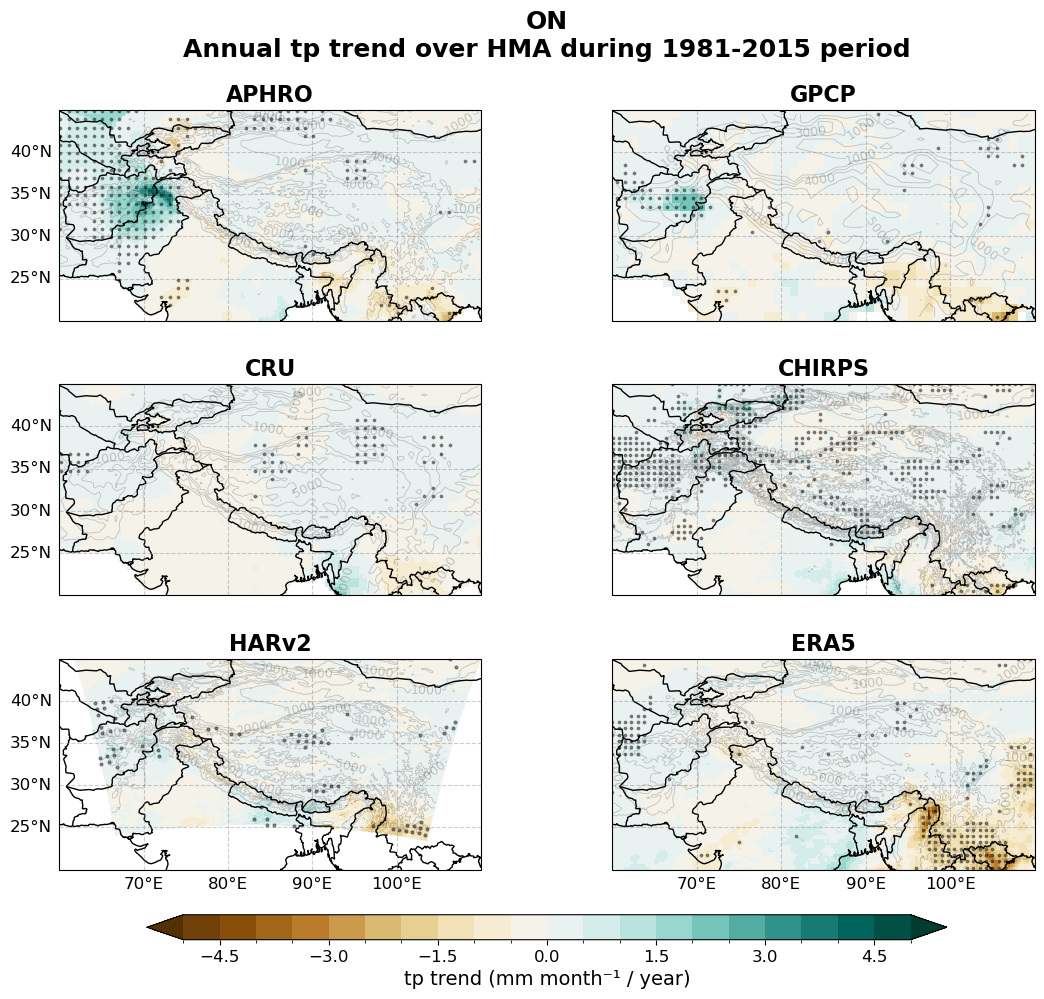

In [26]:
step_p = {
    models[0]: 4,
    models[1]: 1,
    models[2]: 2,
    models[3]: 14,
    models[4]: 8,
    models[5]: 3}

step = 0.5
vmax = 5
#vmax = max(np.round(float(np.nanmax(np.abs(ds))), 1) for ds in trend_annual_dict.values())
print(vmax)
levels = np.linspace(-vmax, vmax, int(2*vmax/step)+1)
cmap = plt.get_cmap("BrBG", len(levels)-1+2)
norm = mcolors.BoundaryNorm(levels, ncolors=cmap.N, extend='both')

fig, axes = plt.subplots(3, 2, figsize=(16, 10), subplot_kw={'projection': ccrs.PlateCarree()})
axes = axes.flatten()

for i, (ax, model) in enumerate(zip(axes, models)):
    #model = models[i]
    data_model = trend_seasonal_dict[model]

    im = ax.pcolormesh(data_model['lon'],data_model['lat'],data_model,transform=ccrs.PlateCarree(),cmap=cmap,norm=norm,shading="auto")

    sig = p_seasonal_dict[model] < 0.05 
    step = step_p[model]
    if model == 'HARv2':
        lon2d = data_model['lon'].values
        lat2d = data_model['lat'].values
        mask = sig.values
        ax.scatter(lon2d[::step, ::step][mask[::step, ::step]],lat2d[::step, ::step][mask[::step, ::step]],
                    color='black',s=4,marker='o',transform=ccrs.PlateCarree(),zorder=5,alpha=0.4)
    else:
        lon_sig, lat_sig = data_model['lon'].values, data_model['lat'].values
        lon_grid, lat_grid = np.meshgrid(lon_sig, lat_sig)
        ax.scatter(lon_grid[::step, ::step][np.where(sig[::step, ::step])],lat_grid[::step, ::step][np.where(sig[::step, ::step])],
               color='black', s=3, marker='o', transform=ccrs.PlateCarree(), zorder=5, alpha=0.4)
    
    ax.set_extent([lonW,lonE,latS,latN], crs=ccrs.PlateCarree())
    
    ax.add_feature(cfeature.COASTLINE, linewidth=1)
    ax.add_feature(cfeature.BORDERS, linestyle="-")

    SH = ax.contour(field_SH_dict[model].lon,field_SH_dict[model].lat,field_SH_dict[model],levels=[1000,2000,3000,4000,5000,6000,7000],
                colors="k",linewidths=0.6,alpha=0.2,transform=ccrs.PlateCarree())
    ax.clabel(SH, inline=True, fontsize=9, fmt="%d")
    
    ax.set_title(model, fontsize=16, weight="bold")

    gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True,linewidth=0.8,color="gray",alpha=0.4,linestyle="--")
    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = (i % 2 == 0)
    gl.bottom_labels = (i >= 4) 
    gl.xlabel_style = {"size": 12}
    gl.ylabel_style = {"size": 12}

# Supprimer les axes inutilisés
for j in range(len(models), len(axes)):
    fig.delaxes(axes[j])
    
cbar_ax = fig.add_axes([0.25, 0.05, 0.5, 0.025])
cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal", extend='both')
cbar.set_label("tp trend (mm month⁻¹ / year)", fontsize=14)
cbar.ax.tick_params(labelsize=12)

fig.subplots_adjust(left=0.08, right=0.92, top=0.88, bottom=0.12, wspace=-0.3, hspace=0.3)
plt.suptitle(f"{season}\nAnnual tp trend over HMA during {iyear}-{fyear} period", fontsize=18, weight="bold")

plt.show()